# Mid-Course Exercise - Assignment 1
**Student Name:** Bálint Décsi
**Date:** January 29, 2026


## Introduction
In this assignment, I will analyze the `AirPassengers` dataset to identify time series patterns, perform seasonal decomposition, and analyze autocorrelation. I've chosen `AirPassengers.csv` as my dataset.


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import warnings
warnings.filterwarnings('ignore')

# Setting the visual style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)


## Task 1: Exploratory Data Analysis (EDA)
First, I will load the dataset and take a look at the first few rows to understand its structure.


In [18]:
# Load the dataset
df = pd.read_csv('AirPassengers.csv')

# Display first 5 rows
print("First 5 rows:")
print(df.head())

# Check data types and missing values
print("Data Info:")
print(df.info())

# Summary statistics
print("Summary Statistics:")
print(df.describe())

First 5 rows:
      Date  Passengers
0  1949-01         112
1  1949-02         118
2  1949-03         132
3  1949-04         129
4  1949-05         121
Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Date        144 non-null    object
 1   Passengers  144 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.4+ KB
None
Summary Statistics:
       Passengers
count  144.000000
mean   280.298611
std    119.966317
min    104.000000
25%    180.000000
50%    265.500000
75%    360.500000
max    622.000000


In [19]:
# Do profiling report and analyze the dataset in browser

import pandas_profiling
profile = pandas_profiling.ProfileReport(df)
profile.to_file("data_profiling_report.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 2/2 [00:00<00:00, 767.77it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

It seems there are no missing values, and the `Passengers` column is integer type. The `Date` is currently an object (string).


## Task 2: Time Series Data Preparation
Now I need to convert the `Date` column to a datetime object and extract some time-based features like Year, Month, etc.


In [20]:
# Convert Date to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Extract features
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Month_Name'] = df['Date'].dt.month_name()
# Week of the year (using ISO calendar)
df['Week_of_Year'] = df['Date'].dt.isocalendar().week

# Set Date as the index
df.set_index('Date', inplace=True)

# Check the new columns
df.head()


,Passengers,Year,Month,Month_Name,Week_of_Year
Date,,,,,
1949-01-01,112,1949,1,January,53
1949-02-01,118,1949,2,February,5
1949-03-01,132,1949,3,March,9
1949-04-01,129,1949,4,April,13
1949-05-01,121,1949,5,May,17


## Task 3: Data Visualization
I will create line plots to visualize the trends. Since the data is monthly, I will plot the monthly data and a yearly aggregation (average). Weekly aggregation is not directly applicable to monthly data without upsampling, so I will skip that to avoid introducing artificial data points.


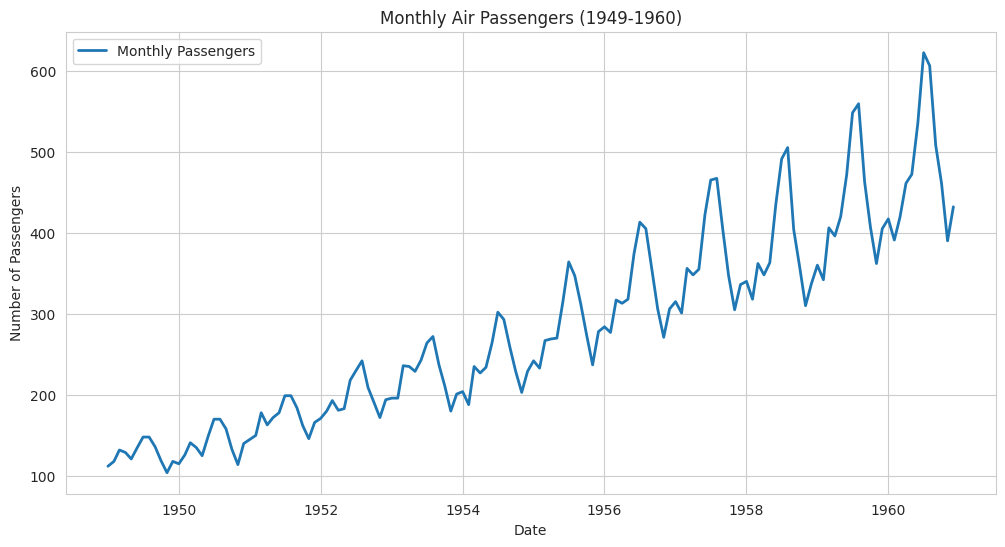

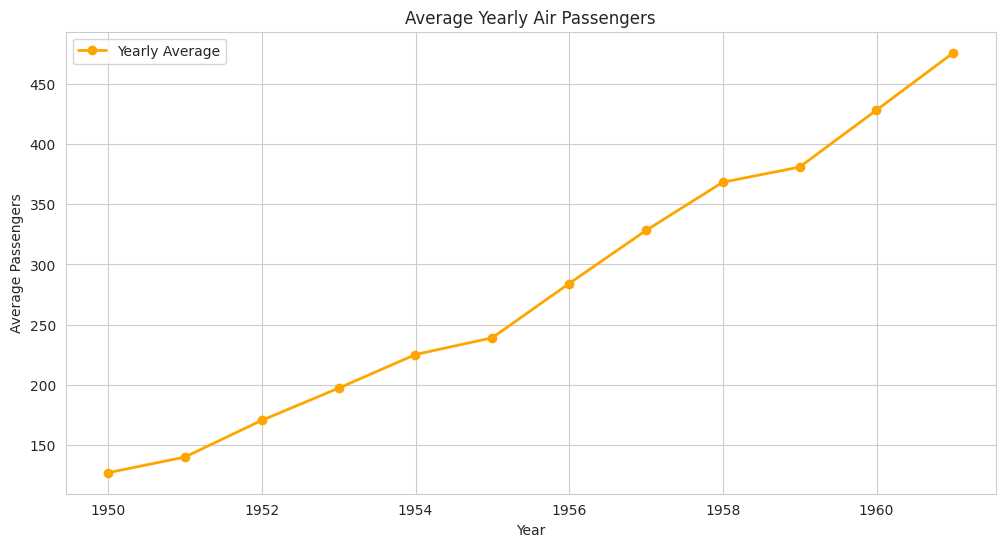

In [7]:
# 1. Monthly Data (Original)
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Passengers'], label='Monthly Passengers', linewidth=2)
plt.title('Monthly Air Passengers (1949-1960)')
plt.xlabel('Date')
plt.ylabel('Number of Passengers')
plt.legend()
plt.show()

# 2. Yearly Aggregation (Mean)
yearly_avg = df['Passengers'].resample('Y').mean()

plt.figure(figsize=(12, 6))
plt.plot(yearly_avg.index, yearly_avg, marker='o', color='orange', label='Yearly Average', linewidth=2)
plt.title('Average Yearly Air Passengers')
plt.xlabel('Year')
plt.ylabel('Average Passengers')
plt.legend()
plt.show()


The line plots show a clear upward trend and a repeating seasonal pattern. The yearly average confirms the steady growth.


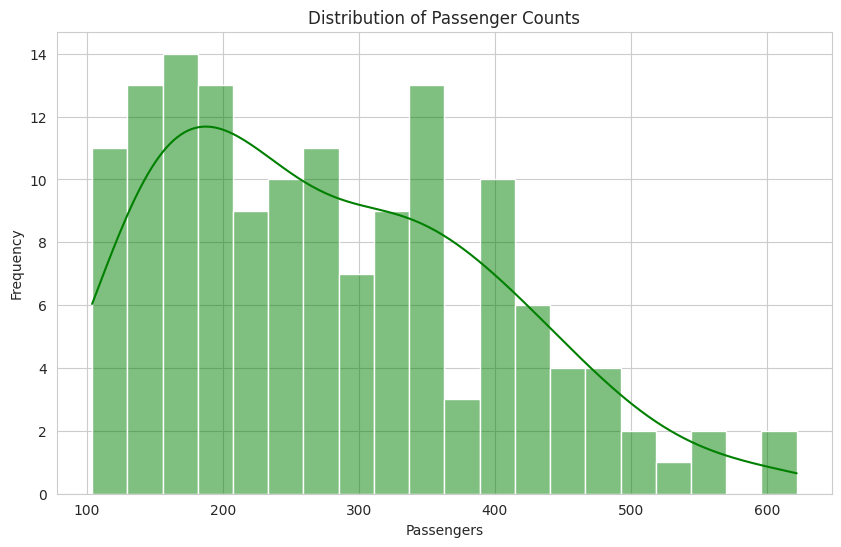

In [21]:
# 3. Histogram of the target variable
plt.figure(figsize=(10, 6))
sns.histplot(df['Passengers'], bins=20, kde=True, color='green')
plt.title('Distribution of Passenger Counts')
plt.xlabel('Passengers')
plt.ylabel('Frequency')
plt.show()


The histogram is slightly right-skewed, showing that lower passenger counts were more common (earlier years) and higher counts are more spread out.


## Task 4: Seasonal Decomposition
I will decompose the time series into Trend, Seasonal, and Residual components. Looking at the first plot, the height of the seasonal waves increases as the trend goes up. This suggests a **multiplicative** model is better than an additive one.


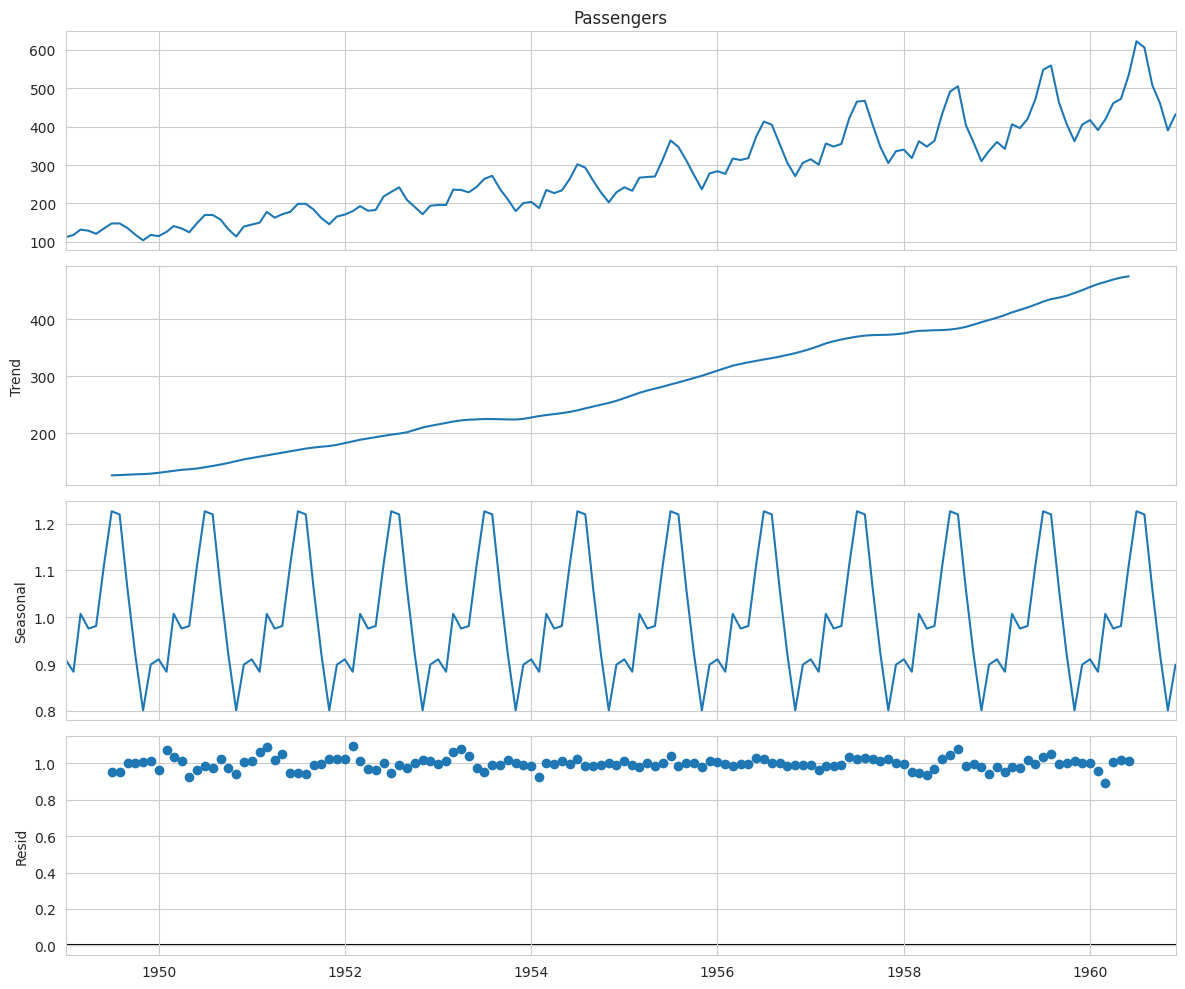

In [10]:
# Perform seasonal decomposition (Multiplicative)
decomposition = seasonal_decompose(df['Passengers'], model='multiplicative', period=12)

# Plot the components
fig = decomposition.plot()
fig.set_size_inches(12, 10)
plt.tight_layout()
plt.show()


The decomposition confirms a strong linear trend and a very clear annual seasonality (period = 12 months). The residuals look mostly random, but there is some variance.


## Task 5: Autocorrelation and Partial Autocorrelation
I will analyze the ACF and PACF plots to understand the correlation structure. I'll also check for stationarity using the Augmented Dickey-Fuller (ADF) test.


--- ADF Test: Original Data ---
ADF Statistic: 0.8153688792060498
p-value: 0.991880243437641
Result: Non-Stationary (Fail to Reject H0)


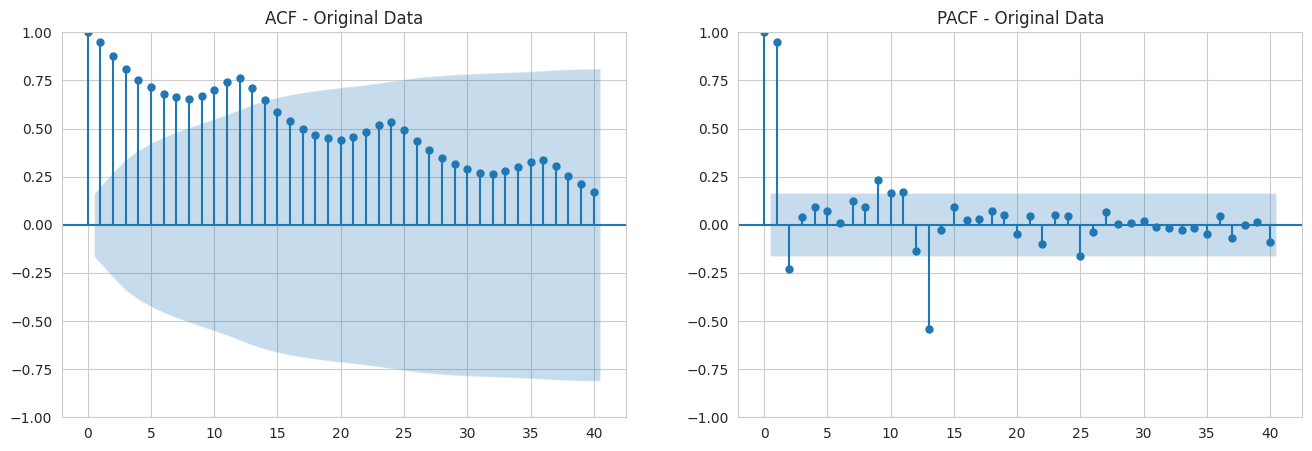

In [11]:
# Function for ADF Test
def print_adf_result(series):
    result = adfuller(series.dropna())
    print('ADF Statistic:', result[0])
    print('p-value:', result[1])
    if result[1] < 0.05:
        print("Result: Stationary (Reject H0)")
    else:
        print("Result: Non-Stationary (Fail to Reject H0)")

# 1. Original Data (Non-Stationary)
print("--- ADF Test: Original Data ---")
print_adf_result(df['Passengers'])

# Plot ACF and PACF
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
plot_acf(df['Passengers'], ax=axes[0], lags=40, title='ACF - Original Data')
plot_pacf(df['Passengers'], ax=axes[1], lags=40, title='PACF - Original Data')
plt.show()


The p-value is high (> 0.05), so the data is non-stationary. The ACF plot decays very slowly, which is a sign of a trend. The PACF has a large spike at lag 1, also typical for non-stationary trended data.


### Making it Stationary
To make the data stationary, I will apply **first-order differencing** to remove the trend. Since the variance is also increasing, I could log-transform first, but I'll start with simple differencing.


--- ADF Test: Differenced Data ---
ADF Statistic: -2.8292668241700047
p-value: 0.05421329028382478
Result: Non-Stationary (Fail to Reject H0)


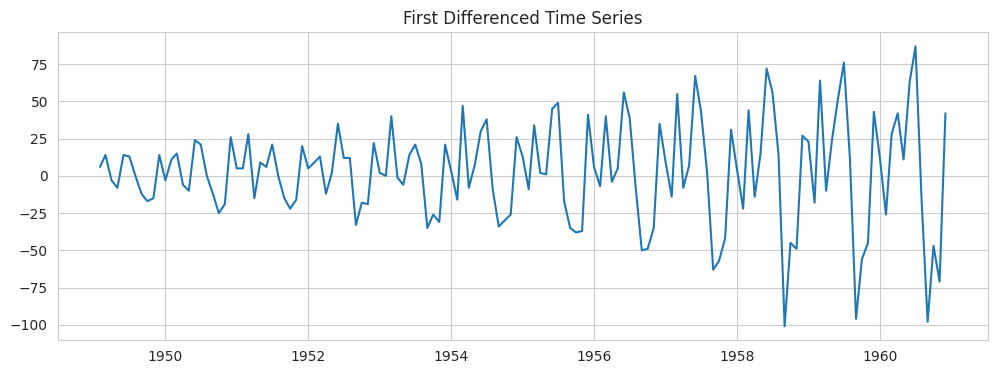

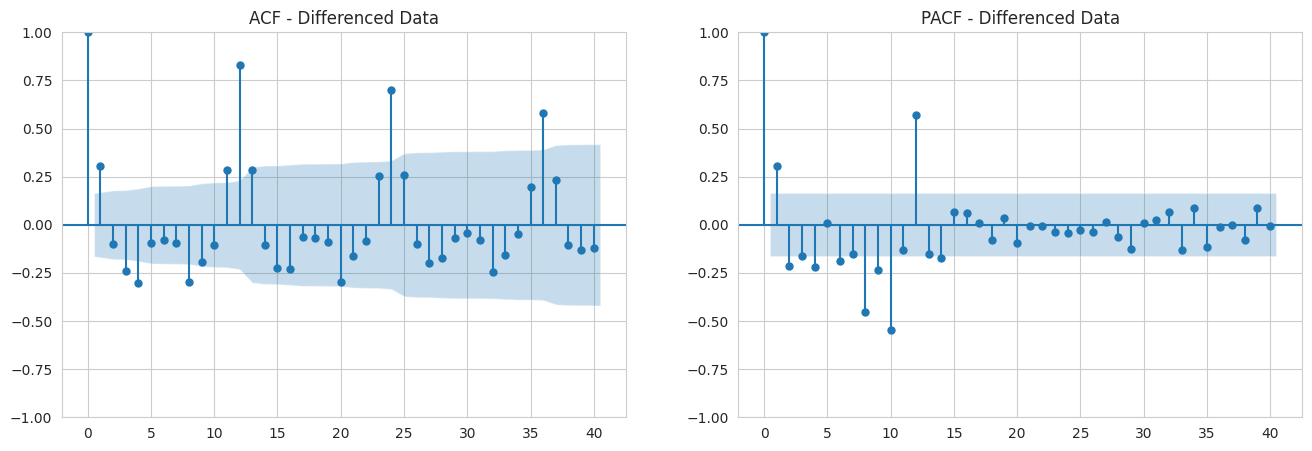

In [22]:
# First Differencing
df_diff = df['Passengers'].diff()

# Check Stationarity again
print("--- ADF Test: Differenced Data ---")
print_adf_result(df_diff)

# Plot Differenced Data
plt.figure(figsize=(12, 4))
plt.plot(df_diff)
plt.title('First Differenced Time Series')
plt.show()

# Plot ACF and PACF for Differenced Data
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
plot_acf(df_diff.dropna(), ax=axes[0], lags=40, title='ACF - Differenced Data')
plot_pacf(df_diff.dropna(), ax=axes[1], lags=40, title='PACF - Differenced Data')
plt.show()


The differenced data might still not be fully stationary (p-value can vary), but the trend is gone. The ACF plot now shows clear spikes at lags 12, 24, 36... which indicates the **seasonality** is still present. We would need seasonal differencing (lag 12) to remove that.


## Task 6: Insights and Conclusions

### Key Patterns and Trends
*   **Trend:** There is a strong, consistent upward trend in air travel from 1949 to 1960.
*   **Seasonality:** There is a distinct annual cycle. Traffic peaks in the summer months (July/August) and is lowest in the cooler months.

### Decomposition
*   I used a **multiplicative** model because the seasonal variation gets larger as the overall number of passengers increases. The decomposition successfully separated the linear trend from the repeating 12-month cycle.

### Stationarity and Transformations
*   The original series is **non-stationary** (ADF p-value > 0.05). 
*   Applying **first-order differencing** removed the linear trend, centering the data around zero. However, the variance still looks a bit unstable (heteroscedasticity), and the seasonal pattern remains.

### Autocorrelation (ACF/PACF)
*   **Original Data:** The ACF drops off very slowly, confirming the trend. High correlation with immediate past values.
*   **Differenced Data:** The ACF shows spikes at multiples of 12 (12, 24, 36), which confirms strong seasonality. This implies that if we were to model this, we would need a **SARIMA** model (Seasonal ARIMA) that accounts for the 12-month lag, not just a simple ARIMA model.

Overall, the analysis shows that AirPassengers is a classic example of a non-stationary time series with both trend and multiplicative seasonality.
